# Data stratification

Notebook demonstrating two methods of splitting FAIR-MAST data by shot ID into training, validation and test folds.

Before applying both methods, the shot indices are shuffled.

The first approach simply assigns a fraction $f$ to the train set, and $1-f/2$ to each of the validation (val) and test sets.

The second approach combines the train and val data from the first approach and assigns K-fold cross-validation fold values to this data. That is, the test set is common between the two approaches.

Shown schematically below:

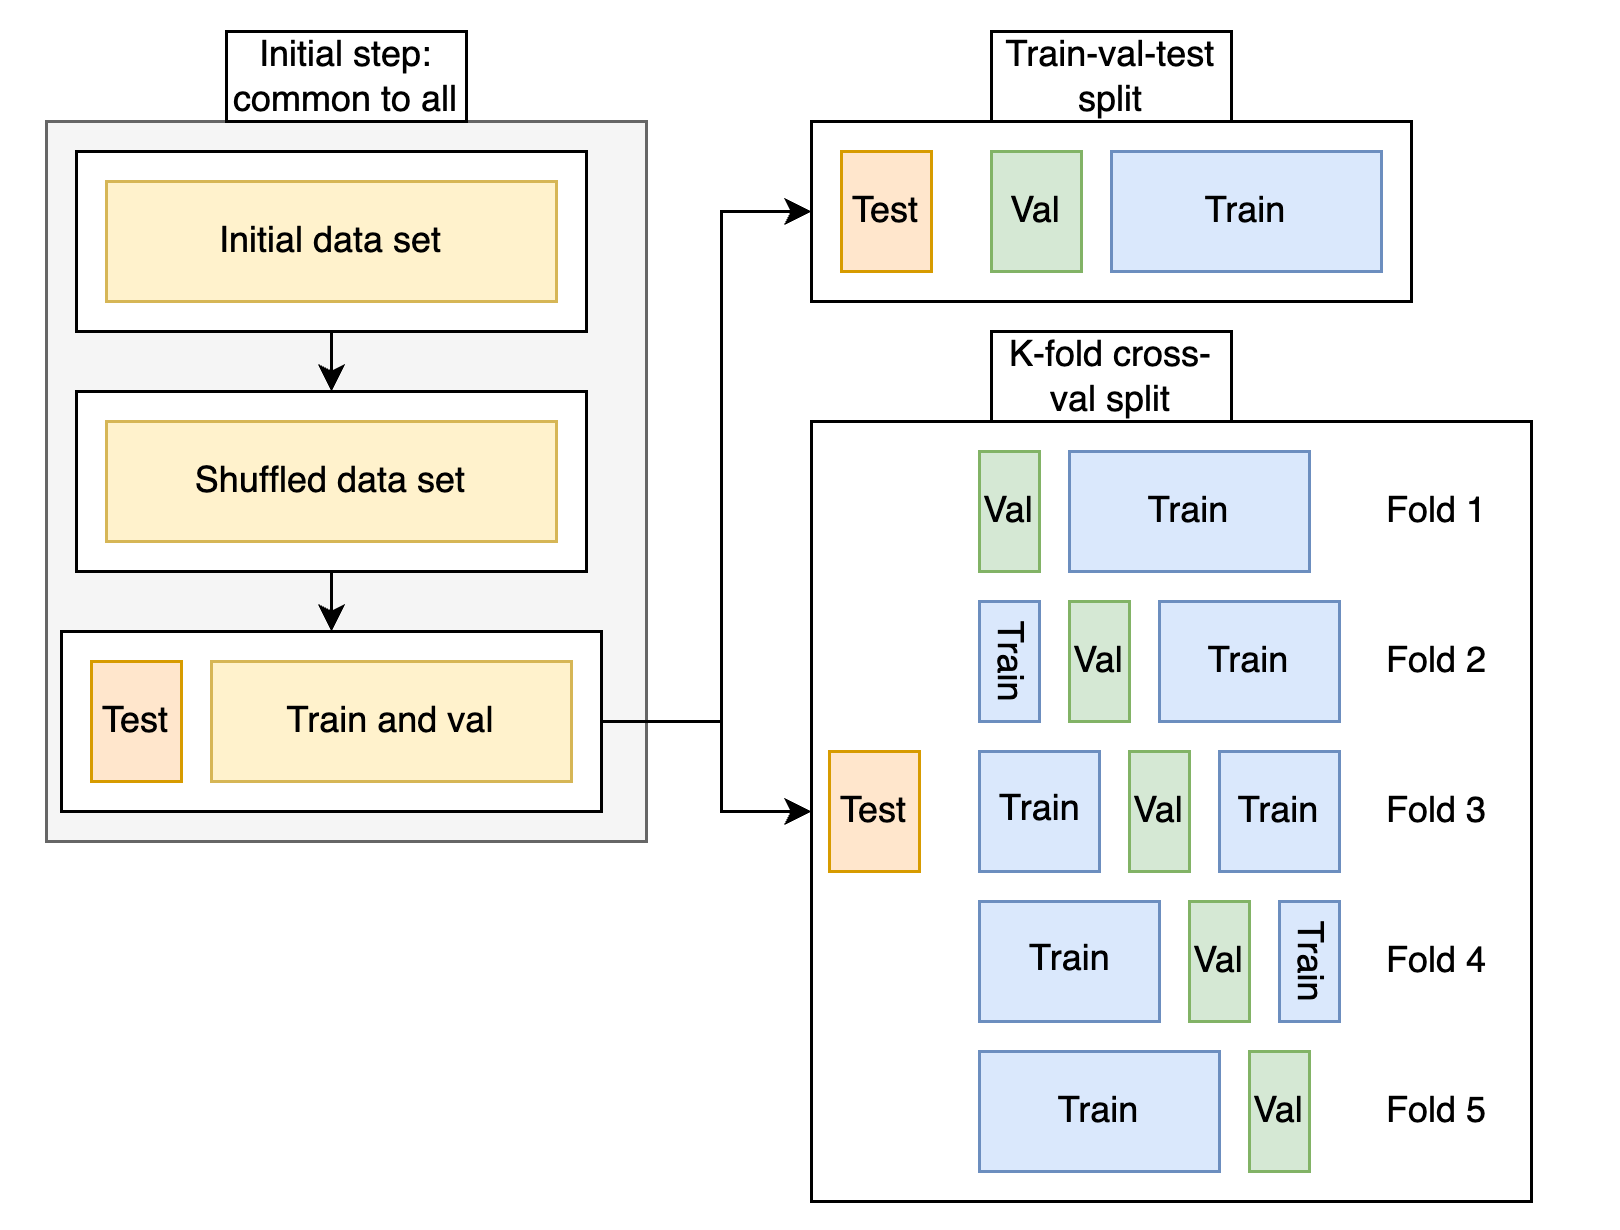

In [1]:
from IPython.display import display, Image
display(Image(filename='train-val-test.png'))

In [1]:
import pandas as pd
from sklearn.model_selection import KFold
import numpy as np
import random

In [2]:
import os
import sys

cwd = os.getcwd()
mast_tools_path = os.path.abspath(os.path.join(cwd, "..", "scripts", "MAST_tools"))
sys.path.append(mast_tools_path)

from store_utils import MASTStorageManager

Define the size of the validation and test sets.

E.g., if val_test_fraction is 0.1, then 10% will be used for testing, 10% for validation, and 80% for training when labelling train/val/test splits. For the K-fold cross-validation folds, 90% of the data will be used for defining folds -- the 80% listed previously as training + the 10% listed previously as validation.

In [3]:
val_test_fraction = 0.1

Load the shot indices and determine split sizes.

In [4]:
msm = MASTStorageManager()
shot_ids = msm.list_all_shots(local=False)
print(len(shot_ids))

random.seed(42)
random.shuffle(shot_ids)

val_test_size = int(len(shot_ids) * val_test_fraction)
train_size = len(shot_ids) - 2 * val_test_size

11573


Split the data according the first approach: train-val-test.

In [5]:
# Split the shot IDs into train, validation, and test sets
train_indices = shot_ids[:train_size]
val_indices = shot_ids[train_size:train_size + val_test_size]
test_indices = shot_ids[train_size + val_test_size:]

# Initialize DataFrame
df = pd.DataFrame(index=shot_ids)

# Create 'train', 'val', and 'test' boolean columns
df['train'] = df.index.isin(train_indices)
df['val'] = df.index.isin(val_indices)
df['test'] = df.index.isin(test_indices)

Split the data according to the second approach: K-fold cross-validation.

In [6]:
# Number of folds for cross-validation
n_splits = 5

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Use the whole train+val set for K-fold
train_val_indices = train_indices + val_indices

# Add fold columns to DataFrame using the entire train+val set
for fold_number, (train_index, val_index) in enumerate(kf.split(train_val_indices), start=1):
    fold_train_col = f'fold_{fold_number}_train'
    fold_val_col = f'fold_{fold_number}_val'

    df[fold_train_col] = False
    df[fold_val_col] = False

    train_fold_indices = np.array(train_val_indices)[train_index]
    val_fold_indices = np.array(train_val_indices)[val_index]

    df.loc[train_fold_indices, fold_train_col] = True
    df.loc[val_fold_indices, fold_val_col] = True

Inspect the dataframe.

Test data is in the `test` column.

Train and val data according to the first method are in the `train` and `val` columns.

The remaining fold train and val data are in the `fold_<n>_<train/test>` columns.

In [7]:
df

,train,val,test,fold_1_train,fold_1_val,fold_2_train,fold_2_val,fold_3_train,fold_3_val,fold_4_train,fold_4_val,fold_5_train,fold_5_val
21719,True,False,False,False,True,True,False,True,False,True,False,True,False
29562,True,False,False,True,False,True,False,True,False,True,False,False,True
27570,True,False,False,True,False,True,False,False,True,True,False,True,False
25984,True,False,False,False,True,True,False,True,False,True,False,True,False
26995,True,False,False,True,False,True,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17963,False,False,True,False,False,False,False,False,False,False,False,False,False
18750,False,False,True,False,False,False,False,False,False,False,False,False,False
12397,False,False,True,False,False,False,False,False,False,False,False,False,False
14481,False,False,True,False,False,False,False,False,False,False,False,False,False


Print fractions of total shots in each set as a simple check.

In [8]:
print(f"Train: {df['train'].sum() / len(shot_ids):.2f}")
print(f"Val:   {df['val'].sum() / len(shot_ids):.2f}")
print(f"Test:  {df['test'].sum() / len(shot_ids):.2f}")

Train: 0.80
Val:   0.10
Test:  0.10


In [9]:
for i in range(1, 6):
    print(f"Fold {i} train: {df[f'fold_{i}_train'].sum() / len(shot_ids):.2f}")
    print(f"Fold {i} val:   {df[f'fold_{i}_val'].sum() / len(shot_ids):.2f}")

Fold 1 train: 0.72
Fold 1 val:   0.18
Fold 2 train: 0.72
Fold 2 val:   0.18
Fold 3 train: 0.72
Fold 3 val:   0.18
Fold 4 train: 0.72
Fold 4 val:   0.18
Fold 5 train: 0.72
Fold 5 val:   0.18
